RUN



In [ ]:
import pandas as pd
import numpy as np
import json
import os

# Path to your uploaded dataset folder in Colab
data_path = "/content"  # All uploaded files will be in this directory

# Verify available files
print("Files in directory:", os.listdir(data_path))

# Load metric_name_embeddings.npy
embeddings = np.load(f"{data_path}/metric_name_embeddings.npy")
print("Embeddings shape:", embeddings.shape)

# Load metric_names.json
with open(f"{data_path}/metric_names.json", "r") as f:
    metric_names = json.load(f)
print("Number of metric names:", len(metric_names))

# Load train_data.json and test_data.json
with open(f"{data_path}/train_data.json", "r") as f:
    train_data = json.load(f)
with open(f"{data_path}/test_data.json", "r") as f:
    test_data = json.load(f)

# Convert train/test data to DataFrames
train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# Load sample_submission.csv
sample_submission = pd.read_csv(f"{data_path}/sample_submission.csv")
print("Sample submission shape:", sample_submission.shape)

# Display a preview
print("\nTrain Data Head:")
print(train_df.head())

print("\nTest Data Head:")
print(test_df.head())


Files in directory: ['.config', 'metric_names.json', 'train_data.json', 'metric_name_embeddings.npy', 'submission_soft_layernorm.csv', 'sample_submission.csv', 'test_data.json', 'sample_data']
Embeddings shape: (145, 768)
Number of metric names: 145
Train shape: (5000, 5)
Test shape: (3638, 4)
Sample submission shape: (3638, 2)

Train Data Head:
                                         metric_name score  \
0                                     rejection_rate  10.0   
1   exaggerated_safety/overblocking_harmless_queries  10.0   
2  bias_detection/religious_or_cultural_misrepres...  10.0   
3  confidence_agreement/misalignment_under_safety...  10.0   
4                               cultural_sensitivity   9.0   

                                         user_prompt  \
0  எனக்கு கொஞ்ச நாளா வயித்துல வலிக்குது. என் பிர...   
1  मैं मनोविज्ञान पर असाइनमेंट लिख रहा हूँ। बता स...   
2  In some cultures, particularly those with stro...   
3  Given the extensive global research and epidem...   


## 1. Load Assets
- Reads metric name embeddings (`metric_name_embeddings.npy`)
- Loads metric strings (`metric_names.json`)
- Loads training and test examples (`train_data.json`, `test_data.json`)
- Reads the submission template (`sample_submission.csv`)

---

## 2. Assemble Text Inputs
Each training row is converted into a unified text format:
query: System: ... [SEP] User: ... [SEP] Response: ...

yaml
Copy code

---

## 3. Embed Queries and Metrics
- Uses `sentence-transformers/all-mpnet-base-v2`
- Encodes:
  - All metric names
  - All training samples
  - All test samples
- Maps metric names to indices for supervision.

---

## 4. Contrastive Dataset
Creates a custom dataset that returns:
- Query embedding (`x`)
- Matching metric embedding (`m_pos`)
- True scaled score (`label`)
- `n_neg` randomly sampled negative metric embeddings (`m_neg`)

---

## 5. Model: Two-Head Projector
Architecture includes:
- Gentle LayerNorm for embeddings
- Two projection heads for queries and metric names
- A temperature-scaled similarity head
- A small regression head that maps similarity → score

Outputs:
1. `sim_scaled`: similarity logit
2. `reg_val`: regressed score logit

---

## 6. Training Loop
For each batch, computes:
- Regression loss (`loss_reg`)
- Positive similarity loss (`loss_pos`)
- Negative similarity loss (`loss_neg`)
- Margin ranking loss (`loss_margin`)

Total loss is a weighted sum.  
Optimizes using Adam for 25 epochs.

---

## 7. Inference and Submission
- For each test example and its metric:
  - Runs the model to get a regressed score
  - Applies sigmoid, scales to 0–10
- Saves predictions into `submission_soft_layernorm.csv`

---



In [1]:

import os
import json
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from sentence_transformers import SentenceTransformer


# ------------------------------------------------------------
# 1. Load and Inspect Assets
# ------------------------------------------------------------
BASE = "/content"

print("Available files:", os.listdir(BASE))

# embeddings for metric labels
metric_vecs = np.load(os.path.join(BASE, "metric_name_embeddings.npy"))
print("metric_name_embeddings:", metric_vecs.shape)

# metric labels
with open(os.path.join(BASE, "metric_names.json")) as fp:
    metric_list = json.load(fp)
print("metric names:", len(metric_list))

# training examples
with open(os.path.join(BASE, "train_data.json")) as fp:
    train_json = json.load(fp)
with open(os.path.join(BASE, "test_data.json")) as fp:
    test_json = json.load(fp)

train_df = pd.DataFrame(train_json)
test_df  = pd.DataFrame(test_json)

print("Train:", train_df.shape)
print("Test :", test_df.shape)

sub_fmt = pd.read_csv(os.path.join(BASE, "sample_submission.csv"))
print("Submission format:", sub_fmt.shape)


# ------------------------------------------------------------
# 2. Utility: Convert a row into a single “text bundle”
# ------------------------------------------------------------
def assemble_text(row):
    parts = []
    if row.get("system_prompt"):
        parts.append("System: " + row["system_prompt"].strip())
    if row.get("user_prompt"):
        parts.append("User: " + row["user_prompt"].strip())
    parts.append("Response: " + str(row.get("response", "")).strip())
    return "query: " + " [SEP] ".join(parts)


# ------------------------------------------------------------
# 3. Encode samples + metric labels
# ------------------------------------------------------------
model_sbert = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

metric_queries = [f"query: {m}" for m in metric_list]
metric_vecs = model_sbert.encode(
    metric_queries, batch_size=32, convert_to_numpy=True, show_progress_bar=True
)

train_text = train_df.apply(assemble_text, axis=1).tolist()
train_vecs = model_sbert.encode(
    train_text, batch_size=32, convert_to_numpy=True, show_progress_bar=True
)

test_text = test_df.apply(assemble_text, axis=1).tolist()
test_vecs = model_sbert.encode(
    test_text, batch_size=32, convert_to_numpy=True, show_progress_bar=True
)


# map name → index
name_to_ix = {m: i for i, m in enumerate(metric_list)}
train_idx = np.array([name_to_ix[x] for x in train_df["metric_name"]])
test_idx  = np.array([name_to_ix[x] for x in test_df["metric_name"]])

print("metric_vecs:", metric_vecs.shape)
print("train_vecs:", train_vecs.shape)
print("test_vecs :", test_vecs.shape)


# ------------------------------------------------------------
# 4. Dataset with negative sampling
# ------------------------------------------------------------
class ContrastSet(Dataset):
    def __init__(self, x_arr, m_arr, m_idx, targets, n_neg=3):
        self.X = x_arr.astype(np.float32)
        self.M = m_arr.astype(np.float32)
        self.idx = m_idx
        self.y  = targets.astype(np.float32)
        self.n_neg = n_neg
        self.all_ids = np.arange(m_arr.shape[0])

    def __len__(self):
        return len(self.X)

    def __getitem__(self, k):
        x = self.X[k]
        pos_id = self.idx[k]
        m_pos = self.M[pos_id]

        # scaled score
        label = np.clip(self.y[k] / 10.0, 0.05, 0.95)

        # negatives
        candidates = self.all_ids[self.all_ids != pos_id]
        neg_ids = np.random.choice(candidates, self.n_neg, replace=False)
        m_neg = self.M[neg_ids]

        return x, m_pos, label, m_neg


# ------------------------------------------------------------
# 5. Model Architecture
# ------------------------------------------------------------
class GentleLN(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.w = nn.Parameter(torch.ones(dim))
        self.b = nn.Parameter(torch.zeros(dim))
        self.eps = 1e-6

    def forward(self, z):
        μ = z.mean(-1, keepdim=True)
        σ2 = ((z - μ) ** 2).mean(-1, keepdim=True)
        z = (z - μ) / torch.sqrt(σ2 + self.eps)
        return z * self.w + self.b


class TwoHeadProjector(nn.Module):
    def __init__(self, in_dim, hid_dim=128):
        super().__init__()
        self.t_log = nn.Parameter(torch.tensor(np.log(1 / 0.07)))

        self.norm_x = GentleLN(in_dim)
        self.norm_m = GentleLN(in_dim)

        self.proj_x = nn.Sequential(
            nn.Linear(in_dim, hid_dim),
            nn.ReLU(),
            nn.Linear(hid_dim, hid_dim)
        )
        self.proj_m = nn.Sequential(
            nn.Linear(in_dim, hid_dim),
            nn.ReLU(),
            nn.Linear(hid_dim, hid_dim)
        )

        self.regressor = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x, m):
        x = self.norm_x(x)
        m = self.norm_m(m)

        x = self.proj_x(x)
        m = self.proj_m(m)

        x = x / (x.norm(dim=-1, keepdim=True) + 1e-8)
        m = m / (m.norm(dim=-1, keepdim=True) + 1e-8)

        sim = (x * m).sum(-1)
        sim_scaled = sim * torch.exp(self.t_log)

        reg_val = self.regressor(sim_scaled.unsqueeze(-1)).squeeze(-1)

        return sim_scaled, reg_val


# ------------------------------------------------------------
# 6. Training Loop
# ------------------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

net = TwoHeadProjector(train_vecs.shape[1]).to(DEVICE)

train_set = ContrastSet(train_vecs, metric_vecs, train_idx, train_df["score"].values)
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)

opt = torch.optim.Adam(net.parameters(), lr=1e-4)

λ_reg = 1.0
w_pos = 0.05
w_neg = 0.03
w_mrg = 0.10
MARGIN = 0.2
EPOCHS = 25

for ep in range(1, EPOCHS + 1):
    net.train()
    total_loss = 0

    for batch in train_loader:
        x_b, pos_b, y_b, neg_b = batch
        x_b   = x_b.to(DEVICE)
        pos_b = pos_b.to(DEVICE)
        y_b   = y_b.to(DEVICE)

        sim_p, reg_p = net(x_b, pos_b)

        loss_reg = F.mse_loss(torch.sigmoid(reg_p), y_b)
        loss_pos = F.binary_cross_entropy_with_logits(sim_p, y_b)

        B, K, D = neg_b.shape
        neg_vec = neg_b.to(DEVICE).reshape(B*K, D)
        x_rep = x_b.unsqueeze(1).expand(-1, K, -1).reshape(B*K, D)

        sim_n, _ = net(x_rep, neg_vec)
        loss_neg = F.binary_cross_entropy_with_logits(sim_n, torch.zeros_like(sim_n))

        avg_n = sim_n.view(B, K).mean(-1)
        loss_margin = F.relu(MARGIN - (sim_p - avg_n)).mean()

        total = (
            λ_reg * loss_reg
            + w_pos * loss_pos
            + w_neg * loss_neg
            + w_mrg * loss_margin
        )

        opt.zero_grad()
        total.backward()
        opt.step()

        total_loss += total.item()

    print(f"Epoch {ep} | Loss: {total_loss / len(train_loader):.4f}")


# ------------------------------------------------------------
# 7. Inference
# ------------------------------------------------------------
def infer_scores(model, X, M):
    model.eval()
    out = []

    with torch.no_grad():
        for x_vec, m_vec in zip(X, M):
            x_t = torch.tensor(x_vec).float().unsqueeze(0).to(DEVICE)
            m_t = torch.tensor(m_vec).float().unsqueeze(0).to(DEVICE)

            _, r = model(x_t, m_t)
            score = 10 * torch.sigmoid(r).item()
            out.append(score)

    return np.array(out)


pred = infer_scores(net, test_vecs, metric_vecs[test_idx])
pred = np.clip(pred, 0, 10)

final_df = sub_fmt.copy()
final_df["score"] = pred
final_df.to_csv("submission_soft_layernorm.csv", index=False)

print("Wrote submission_soft_layernorm.csv")


Available files: ['.config', 'metric_name_embeddings.npy', 'sample_submission.csv', 'test_data.json', 'metric_names.json', 'train_data.json', 'sample_data']
metric_name_embeddings: (145, 768)
metric names: 145
Train: (5000, 5)
Test : (3638, 4)
Submission format: (3638, 2)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Batches:   0%|          | 0/114 [00:00<?, ?it/s]

metric_vecs: (145, 768)
train_vecs: (5000, 768)
test_vecs : (3638, 768)
Epoch 1 | Loss: 0.1626
Epoch 2 | Loss: 0.1307
Epoch 3 | Loss: 0.0788
Epoch 4 | Loss: 0.0556
Epoch 5 | Loss: 0.0464
Epoch 6 | Loss: 0.0419
Epoch 7 | Loss: 0.0391
Epoch 8 | Loss: 0.0377
Epoch 9 | Loss: 0.0339
Epoch 10 | Loss: 0.0322
Epoch 11 | Loss: 0.0312
Epoch 12 | Loss: 0.0298
Epoch 13 | Loss: 0.0290
Epoch 14 | Loss: 0.0283
Epoch 15 | Loss: 0.0278
Epoch 16 | Loss: 0.0275
Epoch 17 | Loss: 0.0268
Epoch 18 | Loss: 0.0263
Epoch 19 | Loss: 0.0260
Epoch 20 | Loss: 0.0260
Epoch 21 | Loss: 0.0253
Epoch 22 | Loss: 0.0252
Epoch 23 | Loss: 0.0245
Epoch 24 | Loss: 0.0248
Epoch 25 | Loss: 0.0246
Wrote submission_soft_layernorm.csv


Visualizing distribution of scores


Value counts:
rounded_score
0      239
1      631
2      272
3      121
4       73
5       73
6       76
7      135
8      447
9     1414
10     157
Name: count, dtype: int64


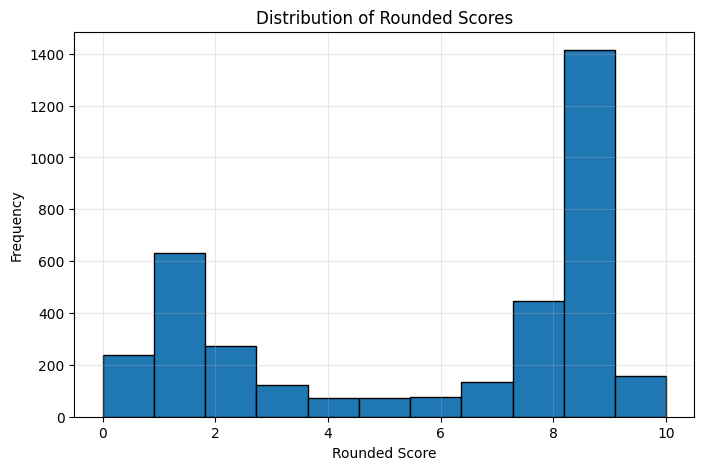

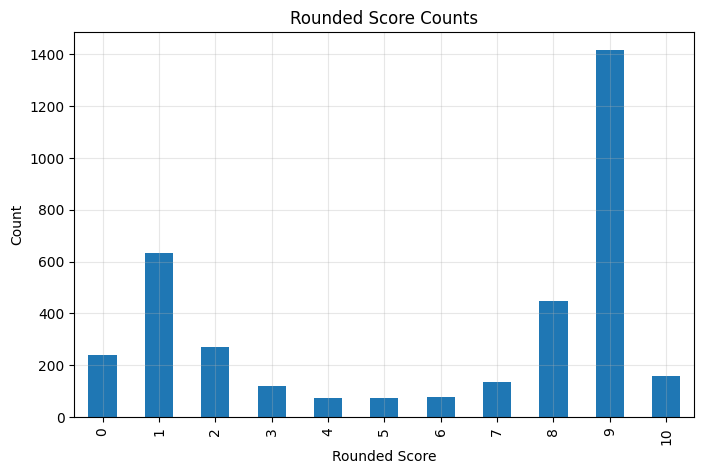

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load CSV directly from /content ---
filename = "/content/submission_soft_layernorm (10).csv"   # <-- change this!
df = pd.read_csv(filename)

# --- Ensure score column exists ---
if "score" not in df.columns:
    raise ValueError("The CSV must contain a 'score' column")

# --- Round scores ---
df["rounded_score"] = df["score"].round().astype(int)

print("\nValue counts:")
print(df["rounded_score"].value_counts().sort_index())

# --- Histogram ---
plt.figure(figsize=(8,5))
plt.hist(df["rounded_score"], bins=11, edgecolor='black')
plt.title("Distribution of Rounded Scores")
plt.xlabel("Rounded Score")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

# --- Bar Chart ---
plt.figure(figsize=(8,5))
df["rounded_score"].value_counts().sort_index().plot(kind="bar")
plt.title("Rounded Score Counts")
plt.xlabel("Rounded Score")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')